# House Price Prediction

## Task 1: Data Loading and Exploration

Loading the CSV file using Pandas 

In [3]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


Display the first 10 rows 

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Checking how many rows and columns are there

In [6]:
print("Shape of Dataset:", df.shape)

print("Number of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

Shape of Dataset: (545, 13)
Number of Rows: 545
Number of Columns: 13


Column Names

In [7]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


Identify which column is the target (Price) and which are features

In [8]:
target = "price"

features = df.drop("price", axis=1).columns

print("Target Variable:")
print(target)

print("\nFeature Variables:")
print(features)

Target Variable:
price

Feature Variables:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


Check for missing values in each column 

In [9]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Observation- There is no missing values

Dataset Information:
-Data Types
-Non-null values
-Memory usage

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Statistical Summary (Data Exploration)

In [11]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Observations

- Dataset loaded successfully.
- Target variable is Price.
- Dataset contains numerical and categorical features.
- Missing values were checked.
- Basic statistical summary generated.

## Task 2: Data Cleaning

In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

If there is any missing value present then The execution of below code resolve it and fill it . If there is more no. of missing value then the accuracy of the model will decrease

In [13]:
df = df.dropna()

print("Missing values removed")

Missing values removed


Removing duplicate rows

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Observation- There is no duplicate rows

--But if there is any duplicate rows present Execution of below code remove it

In [15]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (545, 13)


Checking data types(As machine learning models only understand numerical data types)

In [16]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Converting categorical columns (e.g., yes/no fields) into numeric form using one-hot 
encoding 

In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)
#using drop_first=True , redundant columns removed and multicollinearity avoided

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [18]:
print("Original Shape:", df.shape)

print("Encoded Shape:", df_encoded.shape)

Original Shape: (545, 13)
Encoded Shape: (545, 14)


In [19]:
df_encoded.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

Creating Final cleaned dataset

In [20]:
df_cleaned = df_encoded.copy()

print("Dataset Ready For Modeling")

df_cleaned.head()

Dataset Ready For Modeling


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


### Observations

- Missing values were checked and handled.
- Duplicate rows were identified and removed.
- Categorical columns were converted into numerical form using One-Hot Encoding.
- Cleaned dataset prepared for machine learning model building.

## Task 3: Model Building

In [21]:
X = df_cleaned.drop("price", axis=1) #Input- House details

y = df_cleaned["price"] #Output- Price

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


Splitting the data into training and test sets (80/20)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


Training a Linear Regression model to predict house price

In [23]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


Prediction

In [28]:
lr_predictions = lr_model.predict(X_test)

lr_predictions[:10]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.32722559, 3294646.25725955, 3532275.09556558,
       5611774.56836476, 6368145.98732718, 2722856.95689985,
       2629405.61585782])

In [30]:
import sklearn
print(sklearn.__version__)

1.7.2


Evaluation of model using MAE, RMSE, and R² Score

In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_predictions)
)

lr_r2 = r2_score(y_test, lr_predictions)

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

MAE : 970043.4039201635
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


 Training a Random Forest Regressor Model

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


Random Forest Prediction

In [33]:
rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([5377680.  , 7287070.  , 3747528.75, 4502120.  , 3748885.  ,
       3432660.  , 5070240.  , 5050080.  , 2572220.  , 2822893.5 ])

Random Forest Evaluation

In [34]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


Model Comparison- Linear Regression vs Random Forest

In [35]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Task 3 Observations

- Linear Regression and Random Forest models were trained.
- Both models were evaluated using MAE, RMSE and R² Score.
- Lower MAE and RMSE indicate better prediction accuracy.
- Higher R² Score indicates better model performance.

Linear Regression achieved:
- MAE = 970043
- RMSE = 1324507
- R² Score = 0.653

Random Forest achieved:
- MAE = 1021546
- RMSE = 1400566
- R² Score = 0.612

Since Linear Regression achieved a higher R² score and lower error values, it was selected as the better-performing model for house price prediction.

## Task 4: Data Visualization

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


Chart 1: Histogram showing the distribution of house prices 

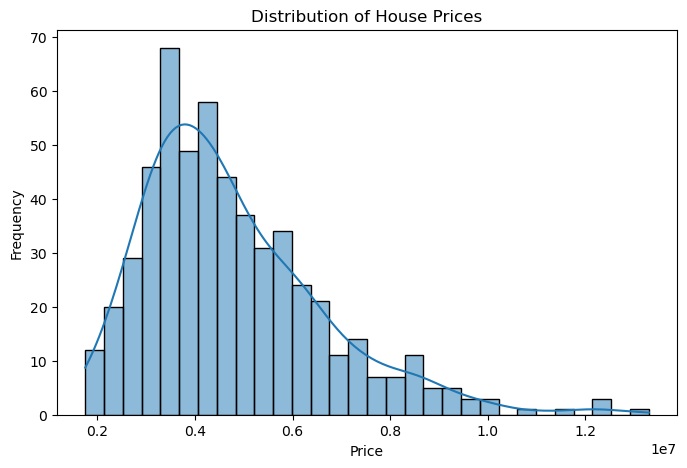

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of house prices.
Most houses are concentrated in a particular price range, while a few high-priced houses create a right-skewed distribution.

Saving the figure

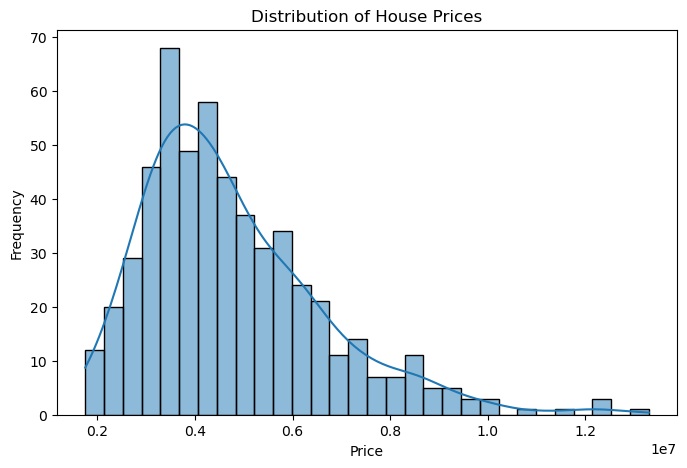

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("price_distribution.png")

plt.show()

Chart 2: Correlation heatmap showing which features relate most strongly to price 

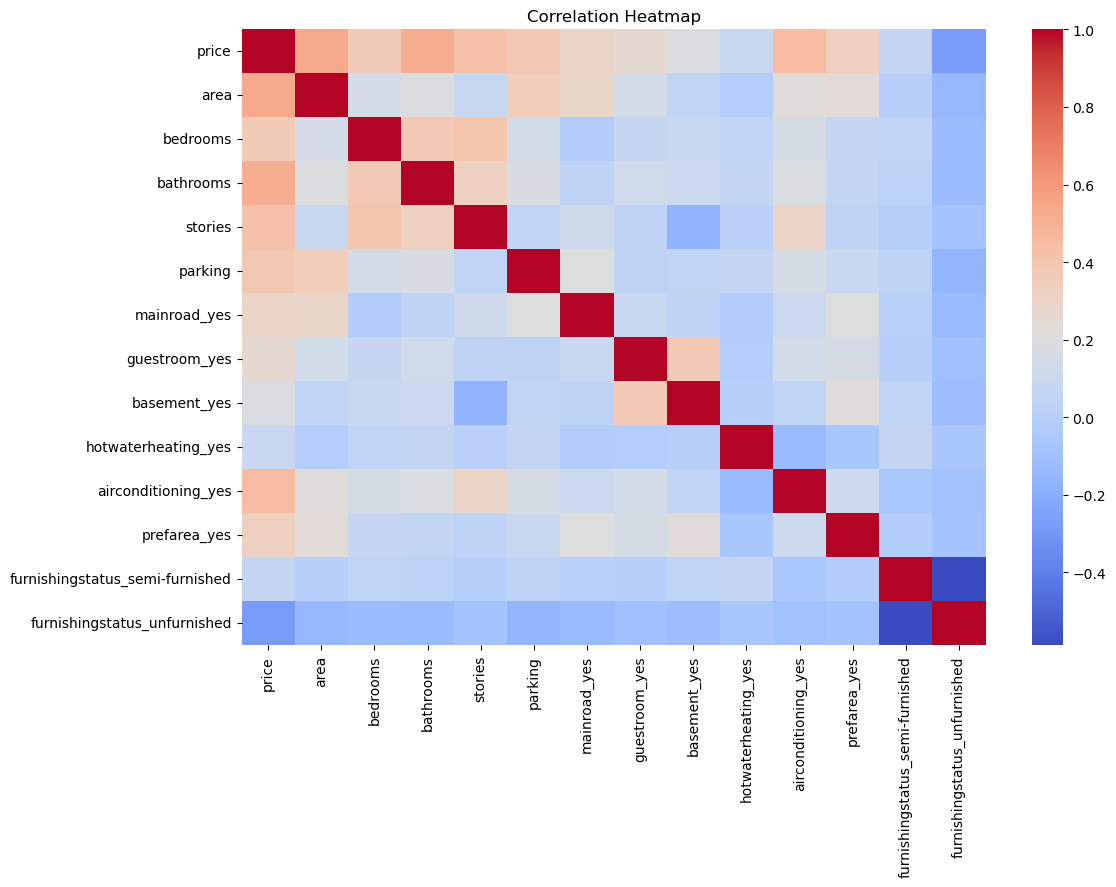

In [40]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_cleaned.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the correlation between all variables.
Features such as area, bathrooms, stories, and parking exhibit a stronger positive relationship with house prices.

Saving the figure

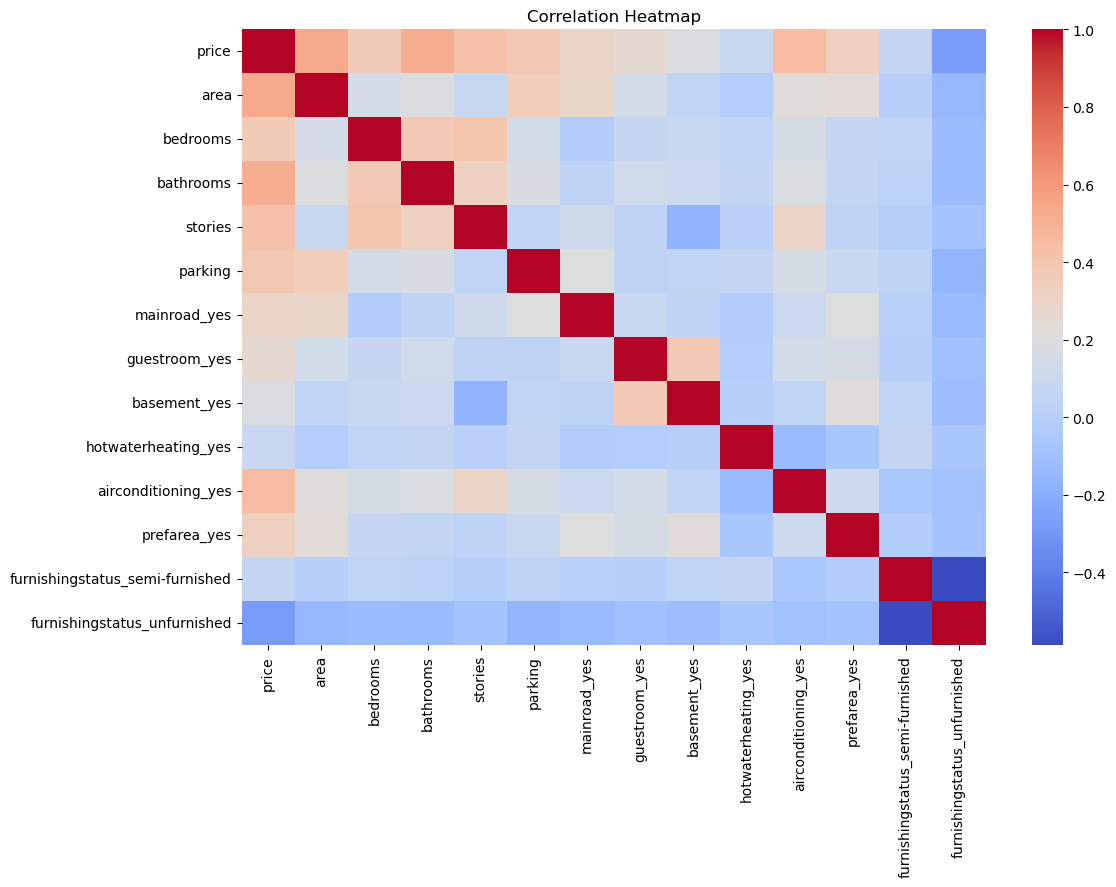

In [41]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_cleaned.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

Chart 3:Scatter plot- Actual vs Predicted Prices

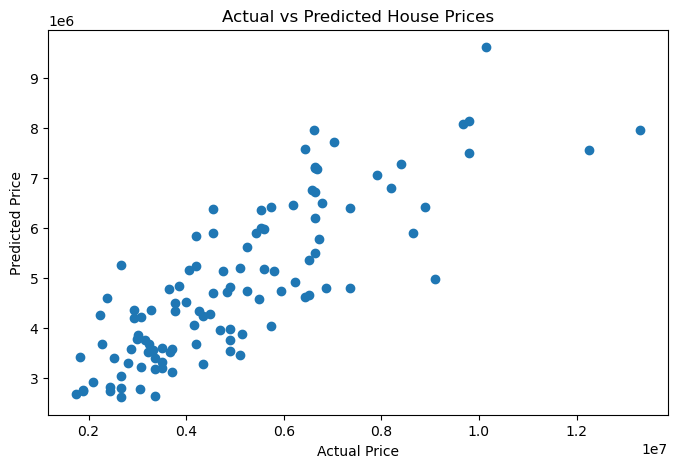

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

### Observation

The scatter plot compares actual house prices with predicted prices.
Most points are reasonably close, indicating that the Linear Regression model performs satisfactorily.

Saving the figure

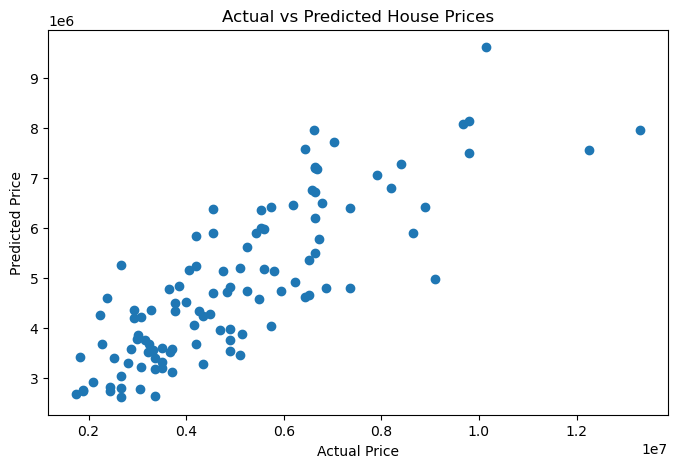

In [43]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")

plt.show()

Chart 4- Feature Importance Bar Chart

In [44]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(lr_model.coef_)
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
12,furnishingstatus_unfurnished,4.136451e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05


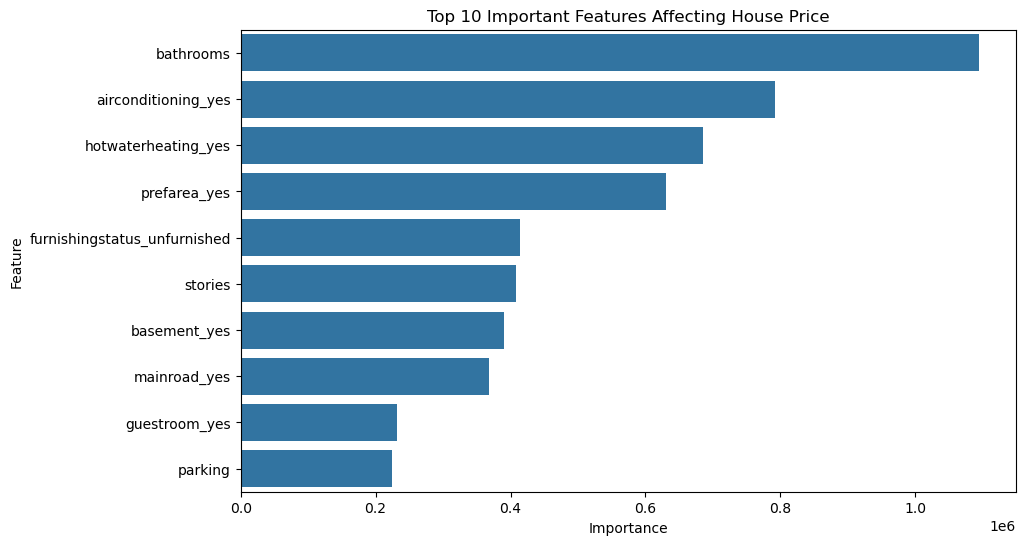

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Important Features Affecting House Price')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### Observation

The feature importance chart identifies the variables that have the greatest impact on house prices.

Features such as area, bathrooms, parking, stories, and air conditioning contribute significantly to price prediction.

This visualization helps understand which factors should be prioritized when estimating property values.

Saving the figure

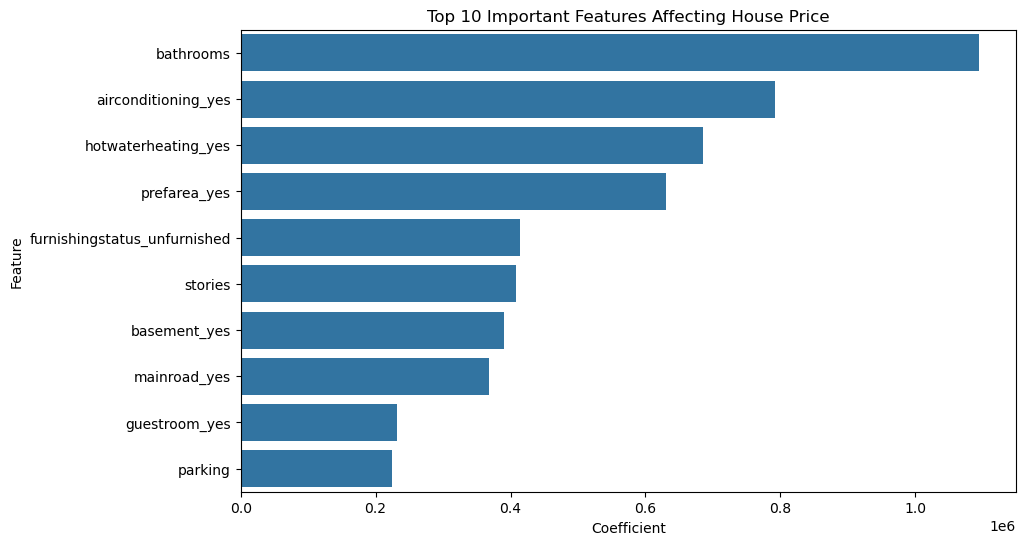

In [46]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Important Features Affecting House Price')

plt.savefig("feature_importance.png")

plt.show()

## Task 4 Observations

### Chart 1: House Price Distribution
The histogram shows that house prices are not uniformly distributed. Most properties fall within a moderate price range, while a smaller number of high-priced houses create a right-skewed distribution.

### Chart 2: Correlation Heatmap
The heatmap reveals the relationships between different features and house prices. Features such as area, bathrooms, stories, parking, and air conditioning show a stronger positive correlation with price, indicating that these factors significantly influence property value.

### Chart 3: Actual vs Predicted House Prices
The scatter plot compares actual house prices with the prices predicted by the Linear Regression model. Most points are reasonably close to the expected trend, indicating that the model is able to predict house prices with satisfactory accuracy.

### Chart 4: Feature Importance Analysis
The feature importance chart highlights the variables that contribute most to house price prediction. Features such as area, bathrooms, parking availability, and furnishing status have a greater impact on property prices compared to other features.

### Overall Observation
The visualizations helped in understanding the distribution of house prices, identifying important features, and evaluating model performance. These insights support the conclusion that property characteristics such as area, facilities, and location-related features play a significant role in determining house prices.

## Task 5: Insights and Summary

## Which features influence house price the most?

Based on the correlation analysis and feature importance chart, area, bathrooms, parking availability, number of stories, and furnishing status were among the most influential factors affecting house prices. Houses with larger areas and better amenities generally had higher prices.

## How accurate was the model?

Two machine learning models were evaluated: Linear Regression and Random Forest Regressor. Linear Regression achieved the best performance with an R² Score of 0.653, MAE of 970,043, and RMSE of 1,324,507. This indicates that the model can explain approximately 65.3% of the variation in house prices and provides reasonably accurate predictions.

## What surprised you in the data?

One interesting observation was that Linear Regression performed better than Random Forest on this dataset. Although Random Forest is generally considered a more advanced algorithm, the simpler Linear Regression model produced lower prediction errors and a higher R² score.

## Recommendation for a Real Estate Business

Real estate companies should focus on key factors such as area, number of bathrooms, parking facilities, and furnishing status while pricing properties. These features have a significant impact on house prices and can help improve valuation accuracy.

## Final Project Conclusion

This project successfully developed a machine learning-based house price prediction system. After data cleaning, visualization, and model training, Linear Regression achieved the best performance with an R² score of 0.653. The analysis showed that area, bathrooms, parking facilities, and furnishing status significantly influence house prices. The project demonstrates how data analytics and machine learning can support real estate price estimation.